Example of training a flow using `glasflow`

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch import optim
import corner

# Update the plotting style
sns.set_context("notebook")
sns.set_palette("colorblind")

### Target distribution. 
Here this is an unconditional 3D Gaussian with random covariance matrix. So far the Bernstein flow requires the target to be defined on the [0,1]^N hypercube, so when sampling from this Gaussian we will set the prior to be 0 outside of this domain (i.e. clip the samples to the [0,1] interval.

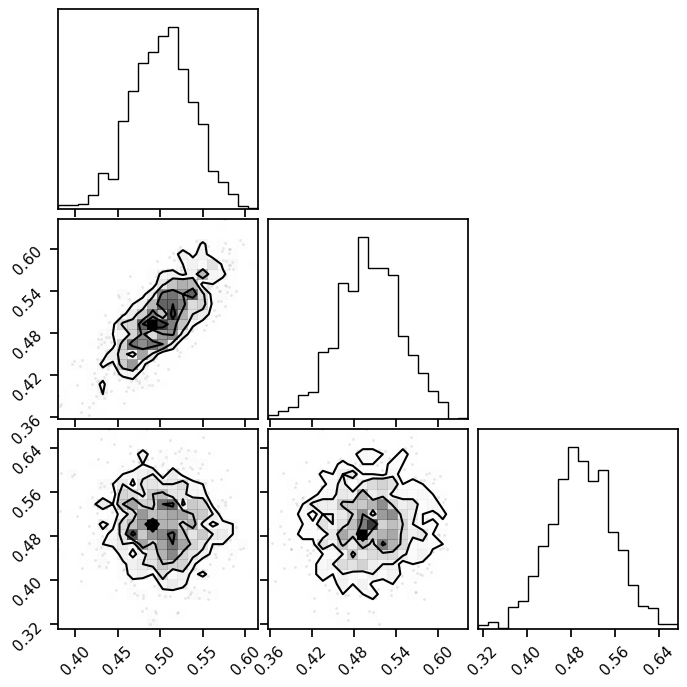

In [20]:
A = (0.5 - np.random.uniform(size=(3,3)))/10
C = np.matmul(A.T,A)
target_samples = np.random.multivariate_normal(mean=[0.5,0.5,0.5], cov=C, size=1000)
corner.corner(target_samples)
plt.show()

### Prepare the flow
Bernstein degree is the polynomial degree of the bernstein transform. If log = True, then the transform calculations will be performed in log space, which should be numerically more stable (although possibly slower).

In [21]:
from glasflow.flows.bpf import CouplingBPF

flow = CouplingBPF(n_inputs=3,
    n_transforms=5,
    n_neurons=32,
    batch_norm_between_transforms=True,
    bernstein_degree=30,
    distribution='uniform',
    log = True
)

In [22]:
optimizer = optim.Adam(flow.parameters())

### Train the flow

In [23]:
num_iter = 500
train_loss = []

for i in range(num_iter):
    t_loss = 0

    x = np.clip(np.random.multivariate_normal(mean=[0.5,0.5,0.5], cov=C, size=1000),0,1)
    x = torch.tensor(x, dtype=torch.float32)
    optimizer.zero_grad()
    loss = -flow.log_prob(inputs=x).mean()
    loss.backward()
    optimizer.step()
    t_loss += loss.item()
    train_loss.append(t_loss)

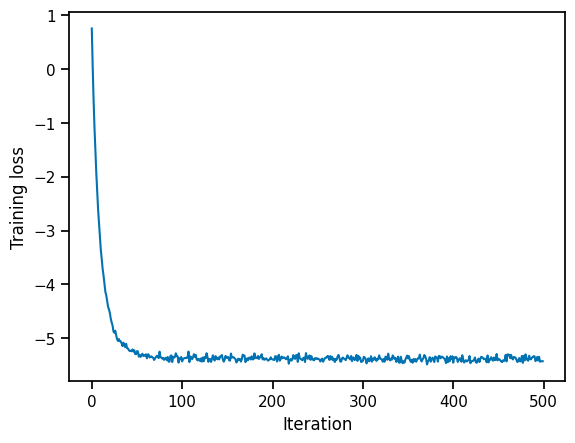

In [24]:
plt.plot(train_loss)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Training loss", fontsize=12)
plt.show()

## Drawing samples from the flow

We can now draw samples from the trained flow and compare them to the target sample.

In [39]:
n = 1000
flow.eval()
with torch.no_grad():
    generated_samples = flow.sample(1000).numpy()

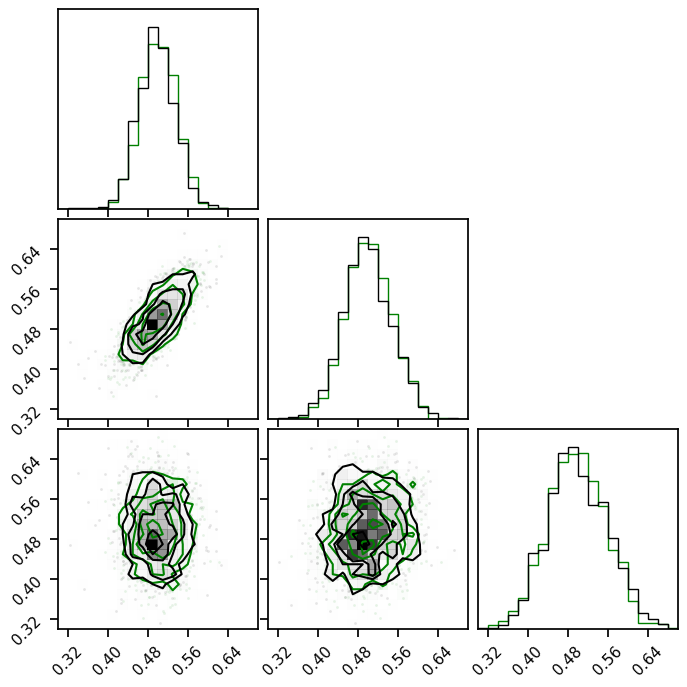

In [47]:
target_samples = np.random.multivariate_normal(mean=[0.5,0.5,0.5], cov=C, size=1000)
range = [[0.3,0.7],[0.3,0.7],[0.3,0.7]]
fig = corner.corner(target_samples, color= 'green', range = range)
corner.corner(generated_samples, fig = fig, weights=np.ones(len(target_samples))*len(generated_samples)/len(target_samples), range = range)

plt.show()